In [2]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHA_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTA_J2000'])


        # Extract Pan-STARRS y-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['yra'])
        dec_panstars = np.array(self.panstarrs_catalog['ydec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat',
                     pan_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(len(matched_decam), "matched DECam entries.")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/y_band_depth.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/Pannstar_casjobs.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


Saved matched DECam to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat
73480 matched DECam entries.
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv


# Y band photometry 


Y-band Zero Point (DES ⇐ PS1)
ZP = 28.1204 ± 0.0039
Stars used = 837


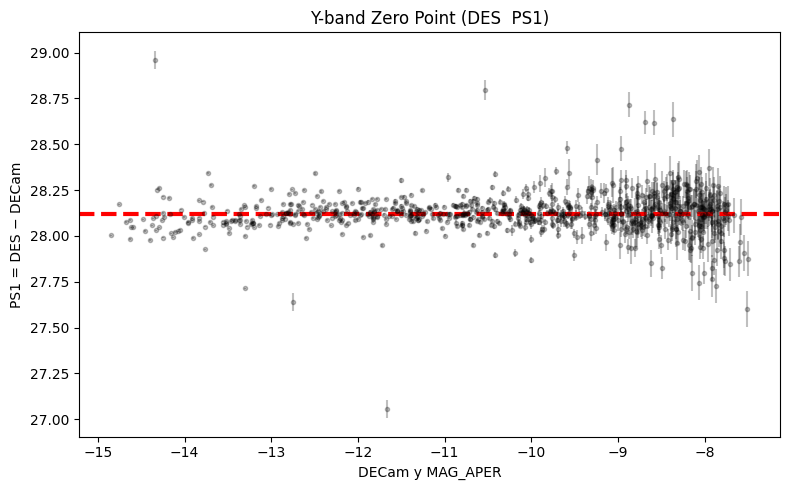

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection from PS1 morphology
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 column helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y-band transform (CORRECT)
# ============================================================
def ps1_to_des_y(ps):
    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rerr = ps_err(ps, 'r')
    ierr = ps_err(ps, 'i')
    yerr = ps_err(ps, 'y')

    # Y_DES = y_PS1 − 0.031 (r − i) + 0.035
    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yerr, 0.031 * np.hypot(rerr, ierr))

    return y_des, y_des_err, (r - i)

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # --------------------------------------------------------
    # Star selection
    # --------------------------------------------------------
    star = is_star_ps1(ps)
    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # --------------------------------------------------------
    # DECam mags
    # --------------------------------------------------------
    m_dec = dec['MAG_APER'].astype(float).values
    m_err = dec['MAGERR_APER'].astype(float).values

    # --------------------------------------------------------
    # PS1 → DES Y
    # --------------------------------------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # --------------------------------------------------------
    # Total error
    # --------------------------------------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # --------------------------------------------------------
    # Valid selection (NO magnitude cuts)
    # --------------------------------------------------------
    good = (
        np.isfinite(m_dec) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &

        # PS1 valid mags
        (ps['yPSFMag'].values > 0) &
        (ps['rPSFMag'].values > 0) &
        (ps['iPSFMag'].values > 0) &
        (ps['yPSFMag'].values < 30) &

        # Color validity
        (color > -0.4) & (color < 2.4) &

        # DECam quality
        (dec['FLAGS'].values == 0) &

        # Remove large-error points
        (sigma_tot < 0.1)
    )

    # Apply mask
    m_dec = m_dec[good]
    y_des = y_des[good]
    err   = sigma_tot[good]

    # --------------------------------------------------------
    # Zero point
    # --------------------------------------------------------
    residuals = y_des - m_dec
    zp = np.median(residuals)
    zp_err = np.std(residuals) / np.sqrt(len(residuals))

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP = {zp:.4f} ± {zp_err:.4f}")
    print(f"Stars used = {len(residuals)}")

    # --------------------------------------------------------
    # QA plot
    # --------------------------------------------------------
    plt.figure(figsize=(8,5))
    plt.errorbar(m_dec, residuals, yerr=err, fmt='k.', alpha=0.25)
    plt.axhline(zp, color='r', lw=3, ls='--')
    plt.xlabel("DECam y MAG_APER")
    plt.ylabel("PS1 = DES − DECam")
    plt.title("Y-band Zero Point (DES  PS1)")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat"
Y_PS    = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv"

run_y_band(Y_DECam, Y_PS)


In [16]:
from astropy.io import fits

# Path to your FITS file
fits_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/c4d_240921_233618_osj_Y_v2.fits.fz"

# Open the FITS file
with fits.open(fits_file) as hdul:
    header = hdul[0].header

# Common zeropoint keywords to check
zp_keys = [
    "ZP", "ZEROPOINT", "MAGZERO", "MAGZPT",
    "PHOTZP", "PHOTZERO", "ABZP", "ZPTMAG"
]

print("Searching for zeropoint keywords...\n")

found = False
for key in zp_keys:
    if key in header:
        print(f"{key} = {header[key]}")
        found = True

if not found:
    print("No zeropoint keyword found in the header.")
        




Searching for zeropoint keywords...

MAGZERO = 28.305
MAGZPT = 22.552


Aperture correction applied: -0.0360 mag

Y-band Zero Point (DES ⇐ PS1)
ZP = 28.4167 ± 0.0044
Stars used = 838


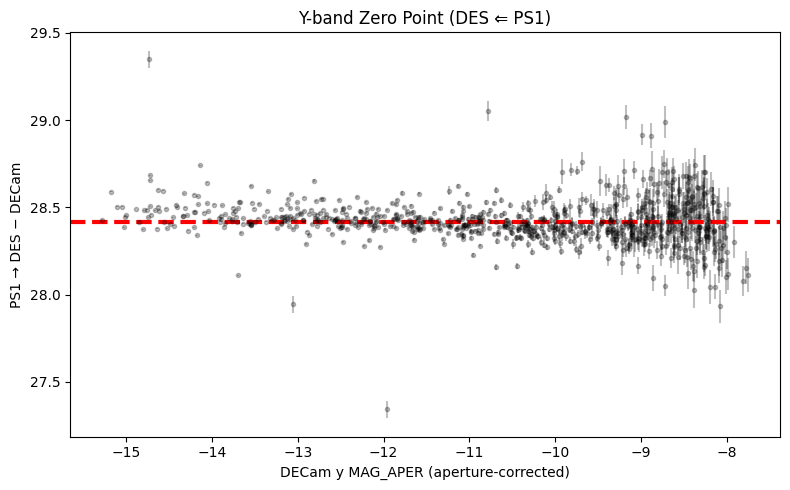

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ============================================================
# USER PARAMETERS (SET THESE)
# ============================================================
APERTURE_RADIUS = 1.0   # arcsec (radius of MAG_APER)
SEEING_FWHM     = 0.9   # arcsec (image seeing FWHM)

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection from PS1 morphology
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 column helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y-band transform
# ============================================================
def ps1_to_des_y(ps):
    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rerr = ps_err(ps, 'r')
    ierr = ps_err(ps, 'i')
    yerr = ps_err(ps, 'y')

    # DES Y transform
    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yerr, 0.031 * np.hypot(rerr, ierr))

    return y_des, y_des_err, (r - i)

# ============================================================
# Aperture correction (2D Gaussian PSF)
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing_fwhm):
    sigma = seeing_fwhm * gaussian_fwhm_to_sigma

    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))

    return flux_tot / flux_ap

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):
    k = calculate_k_constant(aperture_radius, seeing_fwhm)
    return -2.5 * np.log10(k)

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # --------------------------------------------------------
    # Star selection
    # --------------------------------------------------------
    star = is_star_ps1(ps)
    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # --------------------------------------------------------
    # DECam aperture magnitudes
    # --------------------------------------------------------
    m_aper = dec['MAG_AUTO'].astype(float).values
    m_err  = dec['MAGERR_AUTO'].astype(float).values

    # --------------------------------------------------------
    # Aperture correction
    # --------------------------------------------------------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING_FWHM)
    m_dec = m_aper + aper_corr

    print(f"Aperture correction applied: {aper_corr:.4f} mag")

    # --------------------------------------------------------
    # PS1 → DES Y
    # --------------------------------------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # --------------------------------------------------------
    # Total error
    # --------------------------------------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # --------------------------------------------------------
    # Valid selection
    # --------------------------------------------------------
    good = (
        np.isfinite(m_dec) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &

        (ps['yPSFMag'].values > 0) &
        (ps['rPSFMag'].values > 0) &
        (ps['iPSFMag'].values > 0) &
        (ps['yPSFMag'].values < 30) &

        (color > -0.4) & (color < 2.4) &
        (dec['FLAGS'].values == 0) &
        (sigma_tot < 0.1)
    )

    m_dec = m_dec[good]
    y_des = y_des[good]
    err   = sigma_tot[good]

    # --------------------------------------------------------
    # Zeropoint
    # --------------------------------------------------------
    residuals = y_des - m_dec
    zp = np.median(residuals)
    zp_err = np.std(residuals) / np.sqrt(len(residuals))

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP = {zp:.4f} ± {zp_err:.4f}")
    print(f"Stars used = {len(residuals)}")

    # --------------------------------------------------------
    # QA plot
    # --------------------------------------------------------
    plt.figure(figsize=(8,5))
    plt.errorbar(m_dec, residuals, yerr=err, fmt='k.', alpha=0.25)
    plt.axhline(zp, color='r', lw=3, ls='--')
    plt.xlabel("DECam y MAG_APER (aperture-corrected)")
    plt.ylabel("PS1 → DES − DECam")
    plt.title("Y-band Zero Point (DES ⇐ PS1)")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat"
Y_PS    = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv"

run_y_band(Y_DECam, Y_PS)


Aperture correction = -0.1424 mag

Y-band Zero Point (DES ⇐ PS1)
ZP = 28.3677 ± 0.0029
Stars used = 453


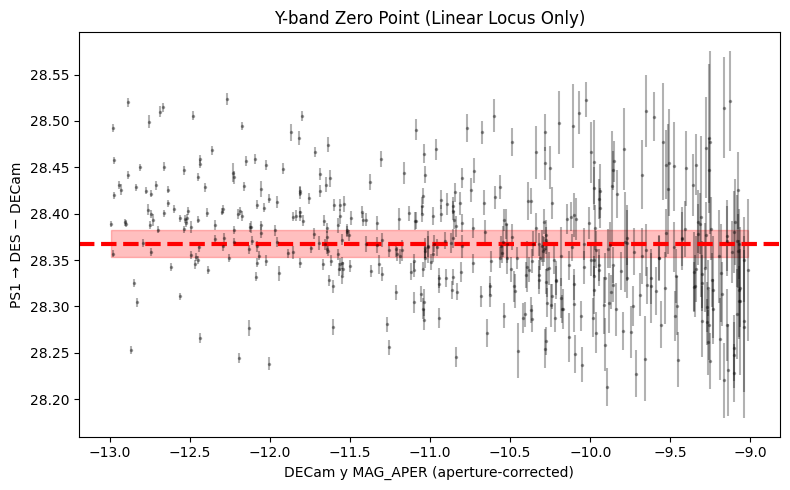

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma, sigma_clip

# ============================================================
# USER PARAMETERS
# ============================================================
APERTURE_RADIUS = 1.0   # arcsec
SEEING_FWHM     = 1.15   # arcsec

MAG_RANGE = (-13, -9)   # CLEAN linear regime (adjust if needed)
NSIGMA_CLIP = 2.5            # locus width

# ============================================================
# Read catalogs
# ============================================================
def read_decam_catalog(filename):
    return pd.read_csv(filename)

def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ============================================================
# Star selection (PS1 morphology)
# ============================================================
def is_star_ps1(ps):
    return np.abs(ps['iPSFMag'] - ps['iKronMag']) < 0.05

# ============================================================
# PS1 column helpers
# ============================================================
def ps_col(ps, band):
    return ps[f"{band}PSFMag"].astype(float).values

def ps_err(ps, band):
    return ps[f"{band}PSFMagErr"].astype(float).values

# ============================================================
# PS1 → DES Y transform
# ============================================================
def ps1_to_des_y(ps):
    r = ps_col(ps, 'r')
    i = ps_col(ps, 'i')
    y = ps_col(ps, 'y')

    rE = ps_err(ps, 'r')
    iE = ps_err(ps, 'i')
    yE = ps_err(ps, 'y')

    y_des = y - 0.031 * (r - i) + 0.035
    y_des_err = np.hypot(yE, 0.031 * np.hypot(rE, iE))

    return y_des, y_des_err, (r - i)

# ============================================================
# Aperture correction (2D Gaussian PSF)
# ============================================================
def gaussian_2d(r, sigma):
    return r * np.exp(-r**2 / (2 * sigma**2))

def calculate_k_constant_mag(aperture_radius, seeing_fwhm):
    sigma = seeing_fwhm * gaussian_fwhm_to_sigma
    flux_ap, _  = quad(gaussian_2d, 0, aperture_radius, args=(sigma,))
    flux_tot, _ = quad(gaussian_2d, 0, np.inf, args=(sigma,))
    return -2.5 * np.log10(flux_tot / flux_ap)

# ============================================================
# Linear locus selector (KEY PART)
# ============================================================
def select_linear_locus(m_dec, y_des, mag_range, nsigma):
    residuals = y_des - m_dec

    # 1) magnitude window → removes bright/faint ends
    mag_sel = (m_dec > mag_range[0]) & (m_dec < mag_range[1])

    # 2) sigma clipping in residual space
    clipped = sigma_clip(residuals[mag_sel],
                          sigma=nsigma,
                          maxiters=5)

    good = mag_sel.copy()
    good[mag_sel] &= ~clipped.mask

    return good

# ============================================================
# Main pipeline
# ============================================================
def run_y_band(decam_path, ps_path):

    dec = read_decam_catalog(decam_path)
    ps  = read_ps_catalog(ps_path)

    # --------------------------------------------------------
    # Star selection
    # --------------------------------------------------------
    star = is_star_ps1(ps)
    dec = dec.loc[star].reset_index(drop=True)
    ps  = ps.loc[star].reset_index(drop=True)

    # --------------------------------------------------------
    # DECam aperture mags
    # --------------------------------------------------------
    m_aper = dec['MAG_AUTO'].astype(float).values
    m_err  = dec['MAGERR_AUTO'].astype(float).values

    # --------------------------------------------------------
    # Aperture correction
    # --------------------------------------------------------
    aper_corr = calculate_k_constant_mag(APERTURE_RADIUS, SEEING_FWHM)
    m_dec = m_aper 
    print(f"Aperture correction = {aper_corr:.4f} mag")

    # --------------------------------------------------------
    # PS1 → DES Y
    # --------------------------------------------------------
    y_des, y_des_err, color = ps1_to_des_y(ps)

    # --------------------------------------------------------
    # Total uncertainty
    # --------------------------------------------------------
    sigma_tot = np.hypot(m_err, y_des_err)

    # --------------------------------------------------------
    # Initial sanity cuts
    # --------------------------------------------------------
    good = (
        np.isfinite(m_dec) &
        np.isfinite(y_des) &
        np.isfinite(sigma_tot) &
        (sigma_tot < 0.1) &
        (color > -0.4) & (color < 2.4) &
        (ps['yPSFMag'] < 30) &
        (dec['FLAGS'] == 0)
    )

    m_dec = m_dec[good]
    y_des = y_des[good]
    err   = sigma_tot[good]

    # --------------------------------------------------------
    # >>> KEEP ONLY LINEAR LOCUS <<<
    # --------------------------------------------------------
    good_locus = select_linear_locus(
        m_dec, y_des,
        mag_range=MAG_RANGE,
        nsigma=NSIGMA_CLIP
    )

    m_dec = m_dec[good_locus]
    y_des = y_des[good_locus]
    err   = err[good_locus]

    # --------------------------------------------------------
    # Zeropoint
    # --------------------------------------------------------
    residuals = y_des - m_dec
    zp = np.median(residuals)
    zp_err = np.std(residuals) / np.sqrt(len(residuals))

    print("\nY-band Zero Point (DES ⇐ PS1)")
    print(f"ZP = {zp:.4f} ± {zp_err:.4f}")
    print(f"Stars used = {len(residuals)}")

    # --------------------------------------------------------
    # QA plot
    # --------------------------------------------------------
    x = np.linspace(m_dec.min(), m_dec.max(), 200)

    plt.figure(figsize=(8,5))
    plt.errorbar(m_dec, residuals, yerr=err,
                 fmt='k.', alpha=0.3, ms=3)
    plt.axhline(zp, color='r', lw=3, ls='--')
    plt.fill_between(x, zp - 5*zp_err, zp + 5*zp_err,
                     color='r', alpha=0.25)

    plt.xlabel("DECam y MAG_APER (aperture-corrected)")
    plt.ylabel("PS1 → DES − DECam")
    plt.title("Y-band Zero Point (Linear Locus Only)")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run
# ============================================================
Y_DECam = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat"
Y_PS    = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv"

run_y_band(Y_DECam, Y_PS)


In [11]:
from astropy.io import fits

fits_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/Raw_Files/c4d_210831_053503_osj_z_vik2.fits.fz"

with fits.open(fits_file) as hdul:
    header = hdul[0].header

# Look for likely seeing-related keywords
keywords = ["SEEING", "FWHM", "PSF", "IQ", "IMAGEQ", "HIERARCH"]

for key in header.keys():
    for k in keywords:
        if k in key.upper():
            print(f"{key} = {header[key]} arcsec/pixel")


FWHM = 6.141517 arcsec/pixel
FWHMAV = 6.282756 arcsec/pixel


In [19]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHA_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTA_J2000'])


        # Extract Pan-STARRS y-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['yra'])
        dec_panstars = np.array(self.panstarrs_catalog['ydec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat',
                     pan_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(len(matched_decam), "matched DECam entries.")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_depth.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/Pannstar_casjobs.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


Saved matched DECam to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat
73874 matched DECam entries.
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_ydepth_new.csv


Median FWHM = 1.15 arcsec
Std FWHM    = 0.62 arcsec


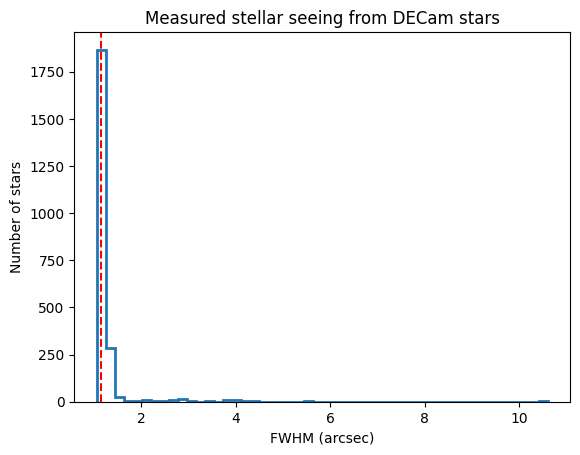

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PIX_SCALE = 0.27  # arcsec / pixel

dec = pd.read_csv(
    "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_ydepth_new.cat"
)

# Select clean stars
stars = (
    (dec['FLAGS'] == 0) &
    (dec['MAG_APER'] < -10) &
    (dec['MAG_APER'] > -16)
)

# Use FLUX_RADIUS (half-light radius)
R50 = dec.loc[stars, 'FLUX_RADIUS'].values  # pixels

# Convert to FWHM
sigma = R50 / 1.177
fwhm_pix = 2.355 * sigma
fwhm_arcsec = fwhm_pix * PIX_SCALE

print(f"Median FWHM = {np.median(fwhm_arcsec):.2f} arcsec")
print(f"Std FWHM    = {np.std(fwhm_arcsec):.2f} arcsec")

# Plot
plt.hist(fwhm_arcsec, bins=50, histtype='step', lw=2)
plt.axvline(np.median(fwhm_arcsec), color='r', ls='--')
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Measured stellar seeing from DECam stars")
plt.show()


# Z band check

In [50]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHA_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTA_J2000'])


        # Extract Pan-STARRS y-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['yra'])
        dec_panstars = np.array(self.panstarrs_catalog['ydec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Idepth_new.cat',
                     pan_out='/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_Idepth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(len(matched_decam), "matched DECam entries.")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_I_depth.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/Pannstar_casjobs.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


Saved matched DECam to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Idepth_new.cat
76123 matched DECam entries.
Saved matched Pan-STARRS to: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_panstars_Idepth_new.csv


Median FWHM = 1.20 arcsec
Std FWHM    = 0.70 arcsec


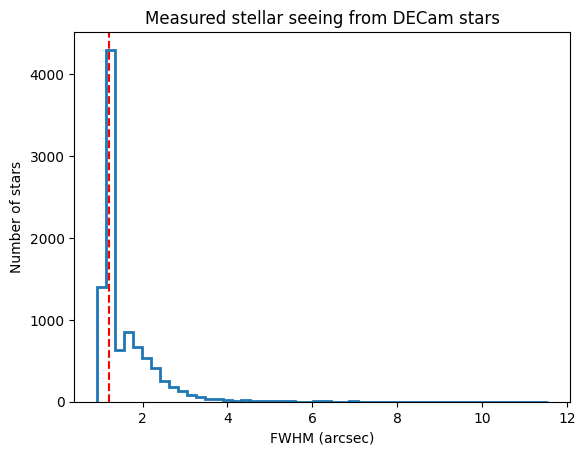

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PIX_SCALE = 0.27  # arcsec / pixel

dec = pd.read_csv(
    "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Idepth_new.cat"
)

# Select clean stars
stars = (
    (dec['FLAGS'] == 0) &
    (dec['MAG_APER'] < -10) &
    (dec['MAG_APER'] > -16)
)

# Use FLUX_RADIUS (half-light radius)
R50 = dec.loc[stars, 'FLUX_RADIUS'].values  # pixels

# Convert to FWHM
sigma = R50 / 1.177
fwhm_pix = 2.355 * sigma
fwhm_arcsec = fwhm_pix * PIX_SCALE

print(f"Median FWHM = {np.median(fwhm_arcsec):.2f} arcsec")
print(f"Std FWHM    = {np.std(fwhm_arcsec):.2f} arcsec")

# Plot
plt.hist(fwhm_arcsec, bins=50, histtype='step', lw=2)
plt.axvline(np.median(fwhm_arcsec), color='r', ls='--')
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Measured stellar seeing from DECam stars")
plt.show()


Stars used        : 53905
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 1.10 arcsec
Std (seeing)      : 0.17 arcsec


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


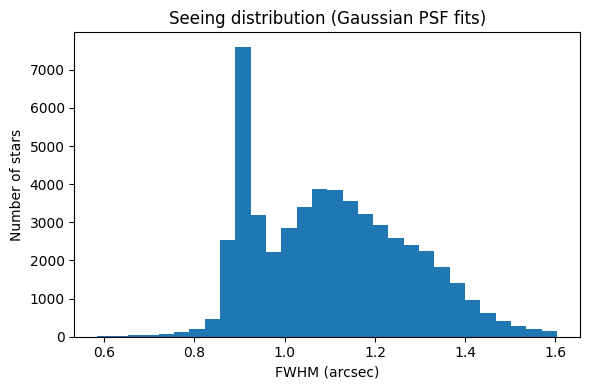

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_mosaic_z.fits"
cat_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Zdepth_new.cat"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load star catalog
# ============================================================
dec = pd.read_csv(cat_file)

# Use correct SExtractor world-coordinate columns
ra  = dec["ALPHA_J2000"].values
dec_ = dec["DELTA_J2000"].values

# Optional: clean stars only
good = (dec["FLAGS"] == 0)
ra, dec_ = ra[good], dec_[good]

# ============================================================
# Convert RA/DEC -> pixel coordinates
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec_*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Gaussian fitting setup
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15   # pixels
half = stamp_size // 2

fwhm_pix = []

# ============================================================
# Loop over stars
# ============================================================
for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    # subtract local background
    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    g_init = models.Gaussian2D(
        amplitude=np.nanmax(stamp),
        x_mean=half,
        y_mean=half,
        x_stddev=2.0,
        y_stddev=2.0
    )

    try:
        g = fitter(g_init, xx, yy, stamp)

        sigma = 0.5 * (g.x_stddev.value + g.y_stddev.value)
        fwhm = 2.355 * sigma

        # sanity cuts in pixels
        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except Exception:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3)

# ============================================================
# Pixel scale (robust for any WCS)
# ============================================================
pixscale_deg = proj_plane_pixel_scales(wcs)[0]   # deg / pixel
pixscale = pixscale_deg * 3600.0                 # arcsec / pixel

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.nanmedian(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.nanstd(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Gaussian PSF fits)")
plt.tight_layout()
plt.show()


Stars used        : 46087
Pixel scale       : 0.270 arcsec / pix
Median seeing     : 1.16 arcsec
Std (seeing)      : 0.16 arcsec


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


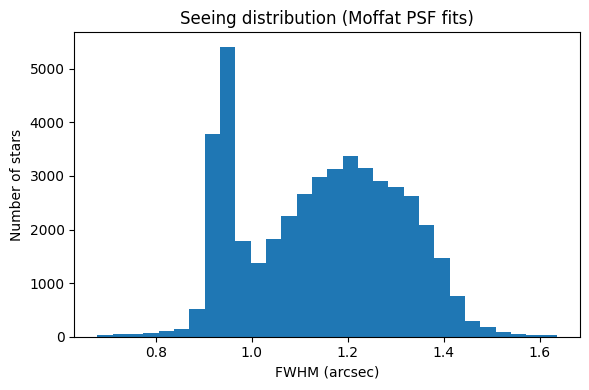

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip

# ============================================================
# File paths
# ============================================================
img_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_mosaic_z.fits"
cat_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Zdepth_new.cat"

# ============================================================
# Load image and WCS
# ============================================================
with fits.open(img_file) as hdu:
    data = hdu[0].data
    header = hdu[0].header

wcs = WCS(header)

# ============================================================
# Load star catalog
# ============================================================
dec = pd.read_csv(cat_file)

# Use correct SExtractor world-coordinate columns
ra  = dec["ALPHA_J2000"].values
dec_ = dec["DELTA_J2000"].values

# Clean stars
good = (dec["FLAGS"] == 0)
ra, dec_ = ra[good], dec_[good]

# ============================================================
# Convert RA/DEC -> pixel coordinates
# ============================================================
coords = SkyCoord(ra=ra*u.deg, dec=dec_*u.deg)
x, y = wcs.world_to_pixel(coords)

# ============================================================
# Fitting setup
# ============================================================
fitter = fitting.LevMarLSQFitter()

stamp_size = 15
half = stamp_size // 2

fwhm_pix = []

# ============================================================
# Loop over stars
# ============================================================
for xi, yi in zip(x, y):

    if not np.isfinite(xi) or not np.isfinite(yi):
        continue

    xi, yi = int(xi), int(yi)

    if (xi < half or yi < half or
        xi + half >= data.shape[1] or
        yi + half >= data.shape[0]):
        continue

    stamp = data[yi-half:yi+half, xi-half:xi+half]

    if not np.isfinite(stamp).all():
        continue

    # subtract local background
    stamp = stamp - np.nanmedian(stamp)

    yy, xx = np.mgrid[:stamp.shape[0], :stamp.shape[1]]

    # --------------------------------------------------------
    # Initial Moffat model (Astropy definition)
    # --------------------------------------------------------
    m_init = models.Moffat2D(
        amplitude=np.nanmax(stamp),
        x_0=half,
        y_0=half,
        gamma=2.5,   # pix
        alpha=2.5   # typical ground-based PSF
    )

    try:
        m = fitter(m_init, xx, yy, stamp)

        gamma = m.gamma.value
        alpha = m.alpha.value

        # Moffat FWHM (pixels)
        fwhm = 2.0 * gamma * np.sqrt(2.0**(1.0/alpha) - 1.0)

        # sanity cuts
        if 0.5 < fwhm < 20:
            fwhm_pix.append(fwhm)

    except Exception:
        continue

# ============================================================
# Sigma clipping
# ============================================================
fwhm_pix = np.array(fwhm_pix)
fwhm_pix = sigma_clip(fwhm_pix, sigma=3)

# ============================================================
# Pixel scale
# ============================================================
pixscale = proj_plane_pixel_scales(wcs)[0] * 3600.0  # arcsec / pix

# ============================================================
# Convert to arcsec
# ============================================================
fwhm_arcsec = fwhm_pix * pixscale

# ============================================================
# Results
# ============================================================
print("======================================")
print(f"Stars used        : {len(fwhm_arcsec)}")
print(f"Pixel scale       : {pixscale:.3f} arcsec / pix")
print(f"Median seeing     : {np.nanmedian(fwhm_arcsec):.2f} arcsec")
print(f"Std (seeing)      : {np.nanstd(fwhm_arcsec):.2f} arcsec")
print("======================================")

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6,4))
plt.hist(fwhm_arcsec, bins=30)
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Seeing distribution (Moffat PSF fits)")
plt.tight_layout()
plt.show()


In [37]:
import pandas as pd

cat_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Idepth_new.cat"
dec = pd.read_csv(cat_file)

print(dec.columns)


Index(['NUMBER', 'X_IMAGE', 'Y_IMAGE', 'ALPHA_J2000', 'DELTA_J2000',
       'MAG_APER', 'MAGERR_APER', 'MAG_AUTO', 'MAGERR_AUTO', 'FLUX_RADIUS',
       'FLAGS'],
      dtype='object')


Median seeing = 1.14 arcsec
Scatter       = 0.05 arcsec
Stars used    = 1980


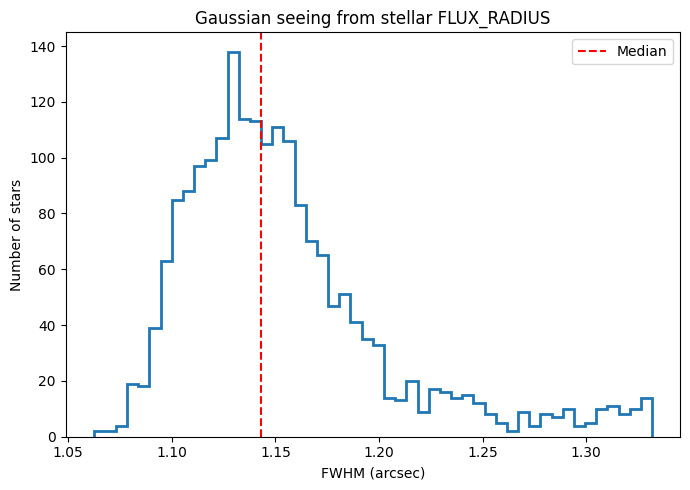

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

PIX_SCALE = 0.27  # arcsec / pixel

dec = pd.read_csv(
    "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/cat_depth/matched_decam_Ydepth_new.cat"
)

# --------------------------------------------------
# Select clean stars
# --------------------------------------------------
stars = (
    (dec['FLAGS'] == 0) &
    (dec['MAG_APER'] < -10) &
    (dec['MAG_APER'] > -16) &
    (dec['FLUX_RADIUS'] > 0)
)

R50 = dec.loc[stars, 'FLUX_RADIUS'].values  # pixels

# --------------------------------------------------
# Convert R50 → sigma → FWHM
# --------------------------------------------------
sigma_pix = R50 / np.sqrt(2 * np.log(2))   # = R50 / 1.177
fwhm_pix  = 2.355 * sigma_pix
fwhm_arcsec = fwhm_pix * PIX_SCALE

# --------------------------------------------------
# Robust clipping
# --------------------------------------------------
clipped = sigma_clip(fwhm_arcsec, sigma=3, maxiters=5)
fwhm_clean = clipped.data[~clipped.mask]

print(f"Median seeing = {np.median(fwhm_clean):.2f} arcsec")
print(f"Scatter       = {np.std(fwhm_clean):.2f} arcsec")
print(f"Stars used    = {len(fwhm_clean)}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(fwhm_clean, bins=50, histtype='step', lw=2)
plt.axvline(np.median(fwhm_clean), color='r', ls='--', label='Median')
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.title("Gaussian seeing from stellar FLUX_RADIUS")
plt.legend()
plt.tight_layout()
plt.show()
